### LGBM & XGBM

#### Objective:
The objective of this assignment is to compare the performance of Light GBM and XG Boost algorithms using the diabetes dataset. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings("ignore")

#### Exploratory Data Analysis (EDA):
1.	Load the Titanic dataset using Python's pandas library.
2.	Check for missing values.
3.	Explore data distributions using histograms and box plots.
4.	Visualize relationships between features and survival using scatter plots and bar plots.

In [2]:
df = pd.read_csv("diabetes.csv")
df.head(7)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1


In [3]:
print("Shape of dataset:", df.shape)

Shape of dataset: (768, 9)


In [4]:
print("Columns:")
print(df.columns.tolist())

Columns:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
stats = pd.DataFrame({
    'Mean': df.mean(numeric_only=True),
    'Median': df.median(numeric_only=True),
    'Mode': df.mode(numeric_only=True).iloc[0],
    'Min': df.min(numeric_only=True),
    'Max': df.max(numeric_only=True),
    'Q1': df.quantile(0.25, numeric_only=True),
    'Q2': df.quantile(0.50, numeric_only=True),
    'Q3': df.quantile(0.75, numeric_only=True)
})
stats['IQR'] = stats['Q3'] - stats['Q1']
stats['Missing Values'] = df.isnull().sum()
stats

,Mean,Median,Mode,Min,Max,Q1,Q2,Q3,IQR,Missing Values
Pregnancies,3.845052,3.0000,1.000,0.000,17.00,1.00000,3.0000,6.00000,5.0000,0
Glucose,120.894531,117.0000,99.000,0.000,199.00,99.00000,117.0000,140.25000,41.2500,0
BloodPressure,69.105469,72.0000,70.000,0.000,122.00,62.00000,72.0000,80.00000,18.0000,0
SkinThickness,20.536458,23.0000,0.000,0.000,99.00,0.00000,23.0000,32.00000,32.0000,0
Insulin,79.799479,30.5000,0.000,0.000,846.00,0.00000,30.5000,127.25000,127.2500,0
BMI,31.992578,32.0000,32.000,0.000,67.10,27.30000,32.0000,36.60000,9.3000,0
DiabetesPedigreeFunction,0.471876,0.3725,0.254,0.078,2.42,0.24375,0.3725,0.62625,0.3825,0
Age,33.240885,29.0000,22.000,21.000,81.00,24.00000,29.0000,41.00000,17.0000,0
Outcome,0.348958,0.0000,0.000,0.000,1.00,0.00000,0.0000,1.00000,1.0000,0


The dataset does not contain explicit null values. However, several physiological variables contain zero values that are not realistic measurements and are therefore treated as missing values during preprocessing.

In [8]:
duplicates = df.duplicated().sum()
print("Duplicates :", duplicates)

Duplicates : 0


In [9]:
zero_columns = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]
zero_counts = (df[zero_columns] == 0).sum()
print("Zero values:")
print(zero_counts)

Zero values:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [10]:
zero_percentage = (
    (df[zero_columns] == 0).sum() / len(df) * 100
).round(2)
print("\nPercentage of zero values:")
print(zero_percentage)


Percentage of zero values:
Glucose           0.65
BloodPressure     4.56
SkinThickness    29.56
Insulin          48.70
BMI               1.43
dtype: float64


In [11]:
print("Outcome counts:")
print(df['Outcome'].value_counts())
print("\nOutcome percentages:")
print(
    df['Outcome']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Outcome counts:
Outcome
0    500
1    268
Name: count, dtype: int64

Outcome percentages:
Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64


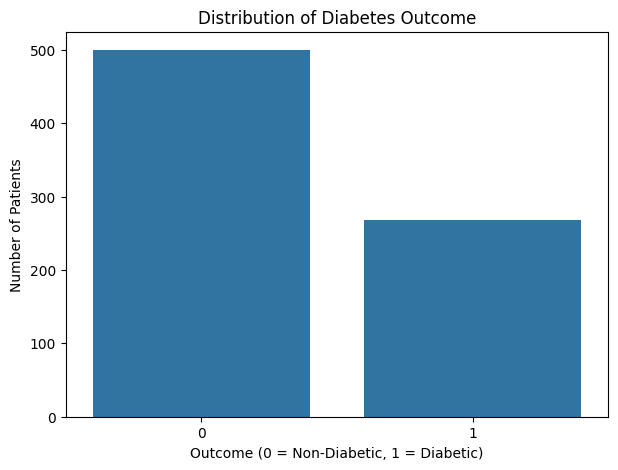

In [12]:
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df,
    x='Outcome'
)
plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Outcome (0 = Non-Diabetic, 1 = Diabetic)")
plt.ylabel("Number of Patients")
plt.show()

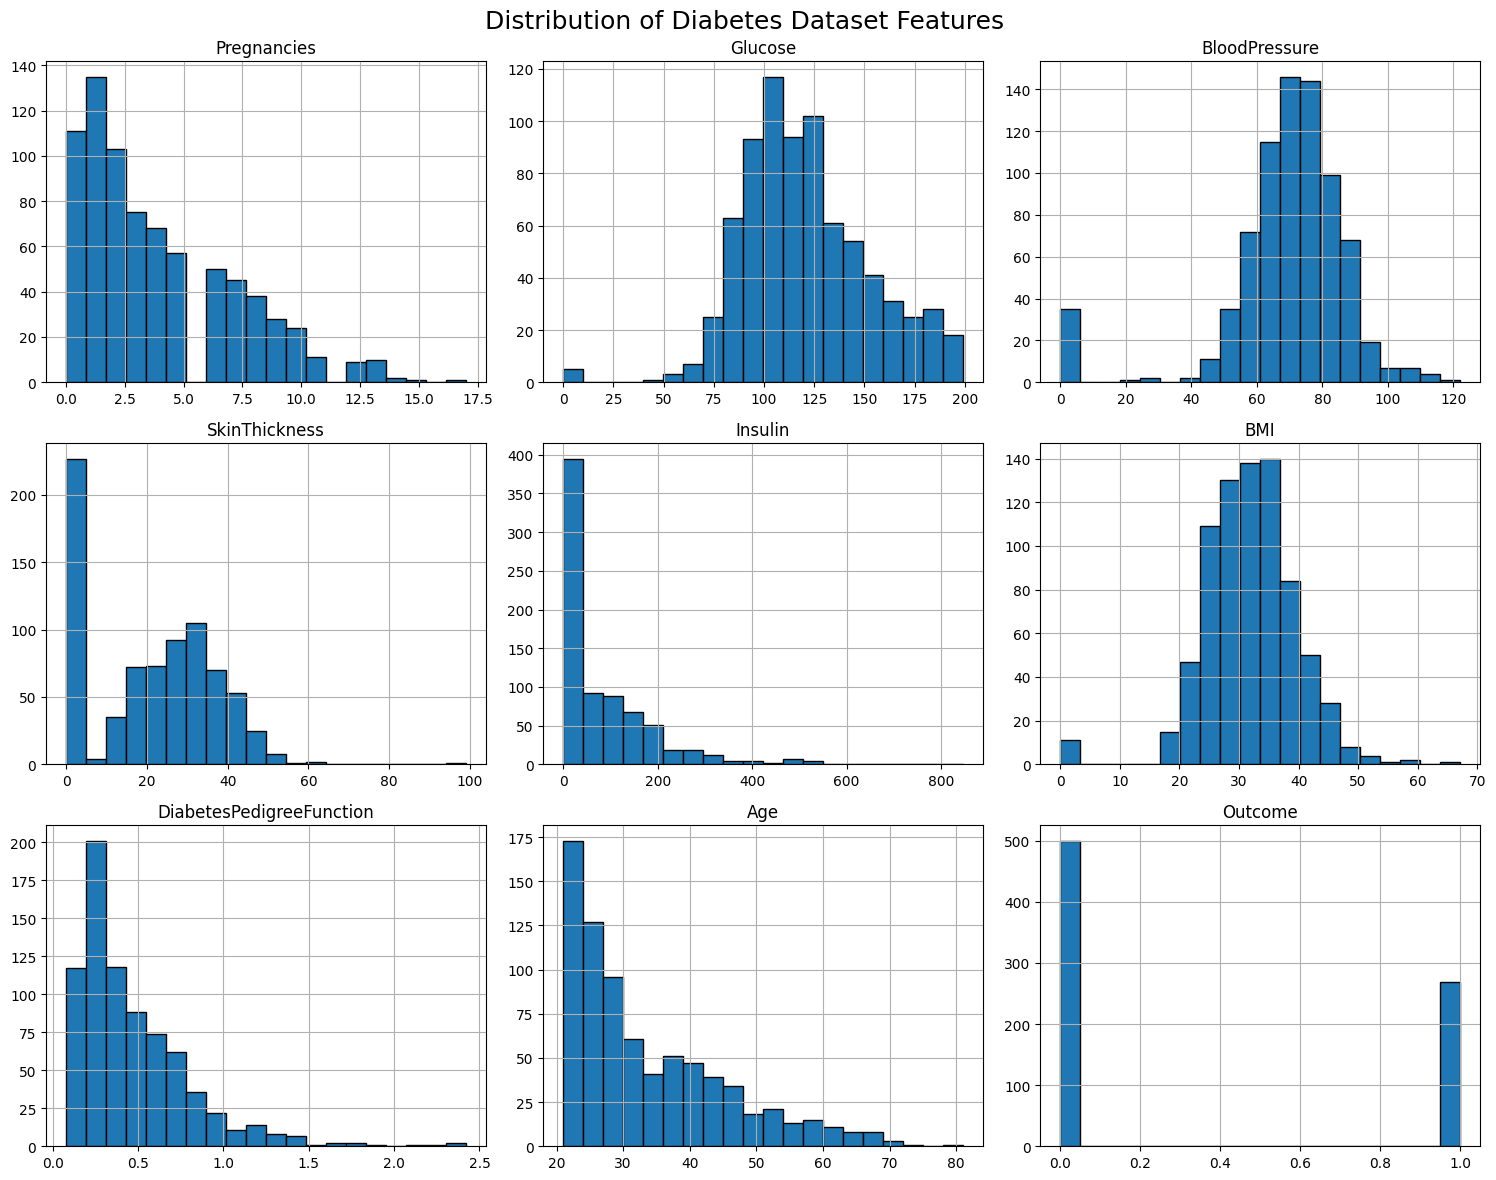

In [13]:
df.hist(
    figsize=(15, 12),
    bins=20,
    edgecolor='black'
)
plt.suptitle(
    "Distribution of Diabetes Dataset Features",
    fontsize=18
)
plt.tight_layout()
plt.show()

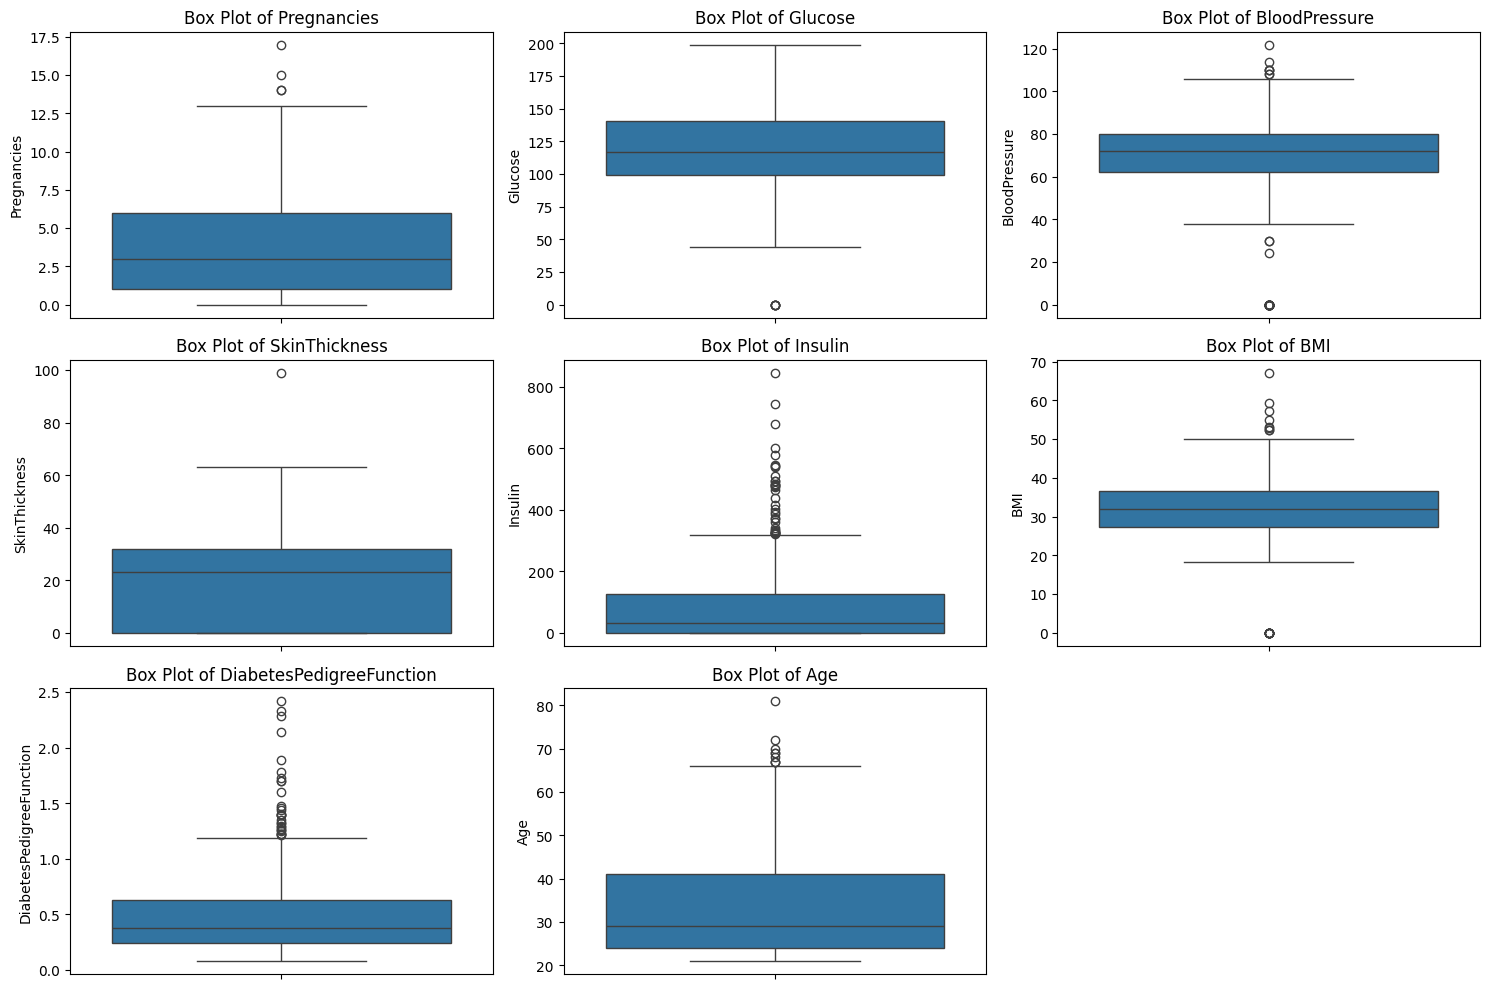

In [14]:
plt.figure(figsize=(15, 10))
for i, column in enumerate(df.columns[:-1], 1):
    plt.subplot(3, 3, i)
    sns.boxplot(
        y=df[column]
    )
    plt.title(f"Box Plot of {column}")
plt.tight_layout()
plt.show()

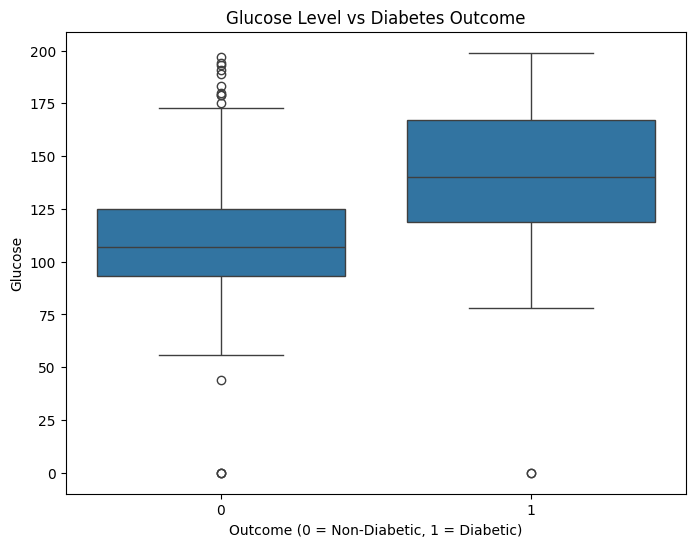

In [15]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df,
    x='Outcome',
    y='Glucose'
)
plt.title("Glucose Level vs Diabetes Outcome")
plt.xlabel("Outcome (0 = Non-Diabetic, 1 = Diabetic)")
plt.ylabel("Glucose")
plt.show()

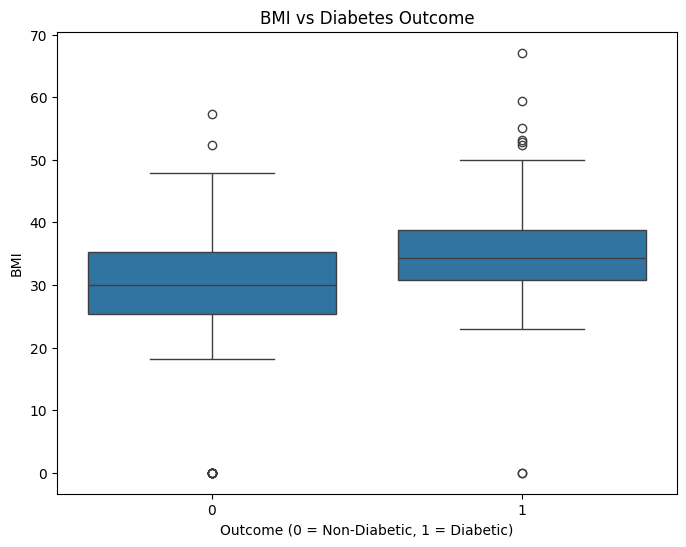

In [16]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df,
    x='Outcome',
    y='BMI'
)
plt.title("BMI vs Diabetes Outcome")
plt.xlabel("Outcome (0 = Non-Diabetic, 1 = Diabetic)")
plt.ylabel("BMI")
plt.show()

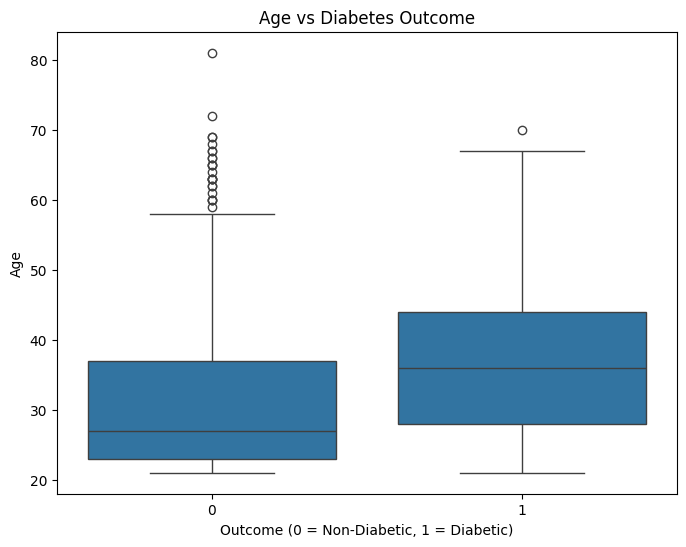

In [17]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df,
    x='Outcome',
    y='Age'
)
plt.title("Age vs Diabetes Outcome")
plt.xlabel("Outcome (0 = Non-Diabetic, 1 = Diabetic)")
plt.ylabel("Age")
plt.show()

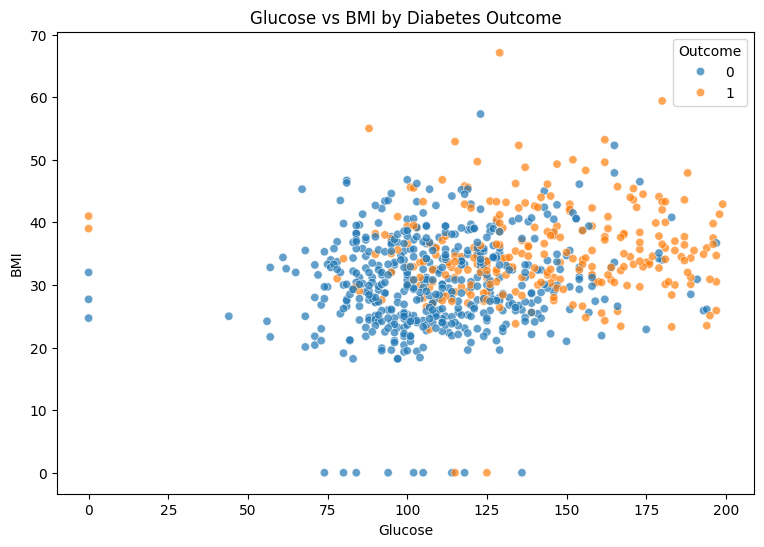

In [18]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='Glucose',
    y='BMI',
    hue='Outcome',
    alpha=0.7
)
plt.title("Glucose vs BMI by Diabetes Outcome")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.show()

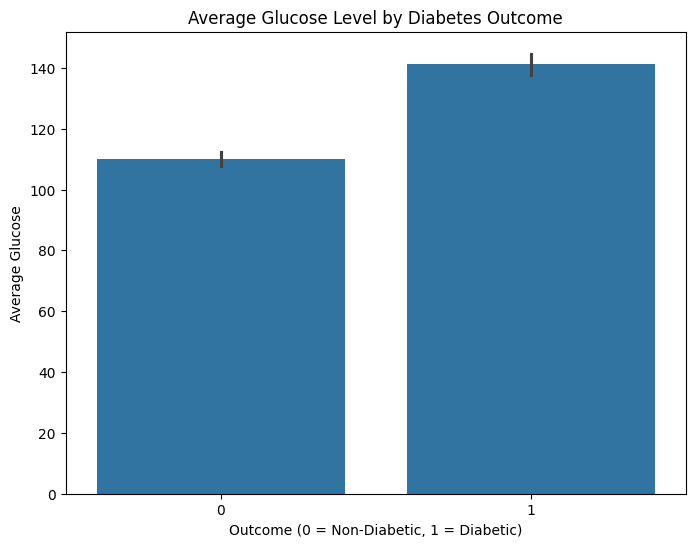

In [19]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=df,
    x='Outcome',
    y='Glucose'
)
plt.title("Average Glucose Level by Diabetes Outcome")
plt.xlabel("Outcome (0 = Non-Diabetic, 1 = Diabetic)")
plt.ylabel("Average Glucose")
plt.show()

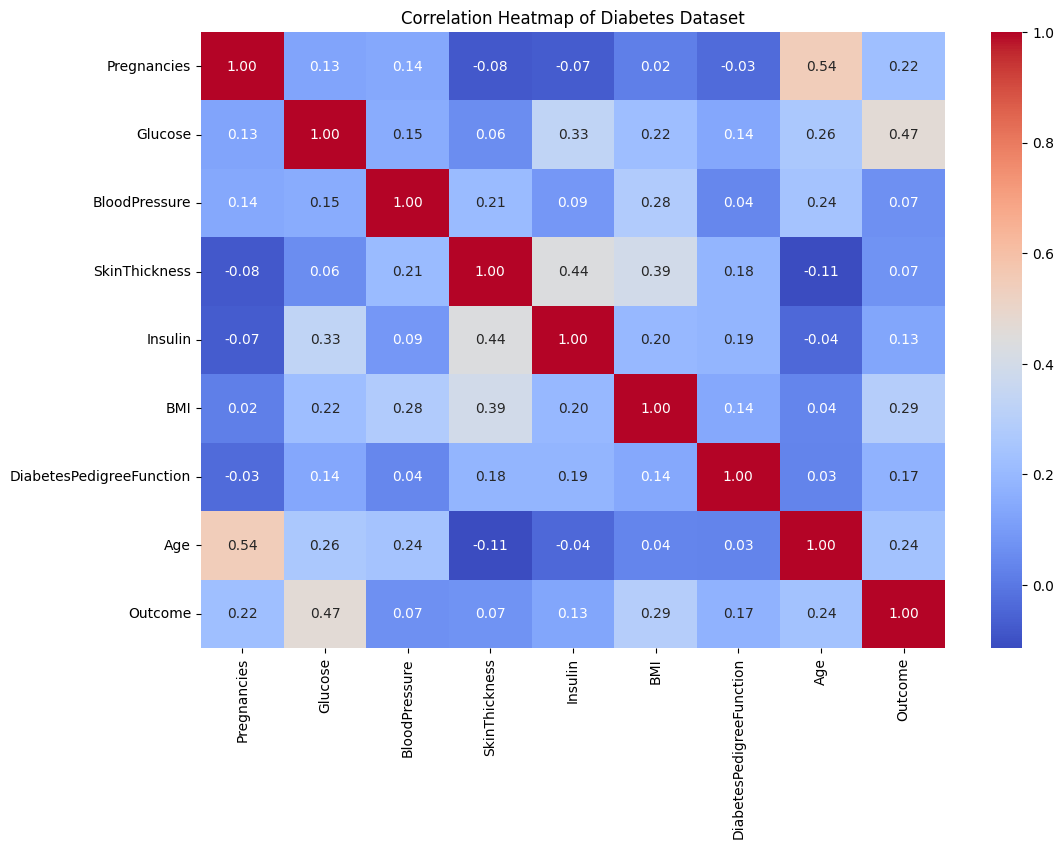

In [20]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Heatmap of Diabetes Dataset")
plt.show()

#### Data Preprocessing:
1.	Impute missing values.
2.	Encode categorical variables using one-hot encoding or label encoding. 
3.	If needed you can apply more preprocessing methods on the given dataset.

In [21]:
df_processed = df.copy()

In [22]:
zero_as_missing = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]
df_processed[zero_as_missing] = (
    df_processed[zero_as_missing]
    .replace(0, np.nan)
)

In [23]:
print("Missing values after replacing invalid zeros:")
print(df_processed.isnull().sum())

Missing values after replacing invalid zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


#### Building Predictive Models:
1.	Split the preprocessed dataset into training and testing sets.
2.	Choose appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score) for model evaluation.
3.	Build predictive models using LightGBM and XGBoost algorithms.
4.	Train the models on the training set and evaluate their performance on the testing set.
5.	Use techniques like cross-validation and hyperparameter tuning to optimize model performance.


In [24]:
X = df_processed.drop(
    'Outcome',
    axis=1
)
y = df_processed['Outcome']
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (768, 8)
Target shape: (768,)


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (614, 8)
Testing data : (154, 8)


In [26]:
imputer = SimpleImputer(
    strategy='median'
)
X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [27]:
print("Missing values in training data:")
print(X_train.isnull().sum())
print("\nMissing values in testing data:")
print(X_test.isnull().sum())

Missing values in training data:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

Missing values in testing data:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


#### Categorical Encoding
No categorical encoding was required because all eight predictor variables in the Diabetes dataset are numerical.

#### Feature Scaling
Feature scaling was not applied because XGBoost and LightGBM are tree-based algorithms and are generally not sensitive to the scale of input features.

In [28]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(
    X_train,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [29]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [30]:
xgb_accuracy = accuracy_score(
    y_test,
    y_pred_xgb
)
xgb_precision = precision_score(
    y_test,
    y_pred_xgb
)
xgb_recall = recall_score(
    y_test,
    y_pred_xgb
)
xgb_f1 = f1_score(
    y_test,
    y_pred_xgb
)
xgb_auc = roc_auc_score(
    y_test,
    y_prob_xgb
)
print("XGBoost Performance")
print("-------------------------")
print("Accuracy :", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall   :", round(xgb_recall, 4))
print("F1 Score :", round(xgb_f1, 4))
print("ROC-AUC  :", round(xgb_auc, 4))

XGBoost Performance
-------------------------
Accuracy : 0.7662
Precision: 0.68
Recall   : 0.6296
F1 Score : 0.6538
ROC-AUC  : 0.8256


In [31]:
print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

              precision    recall  f1-score   support

           0       0.81      0.84      0.82       100
           1       0.68      0.63      0.65        54

    accuracy                           0.77       154
   macro avg       0.74      0.73      0.74       154
weighted avg       0.76      0.77      0.76       154



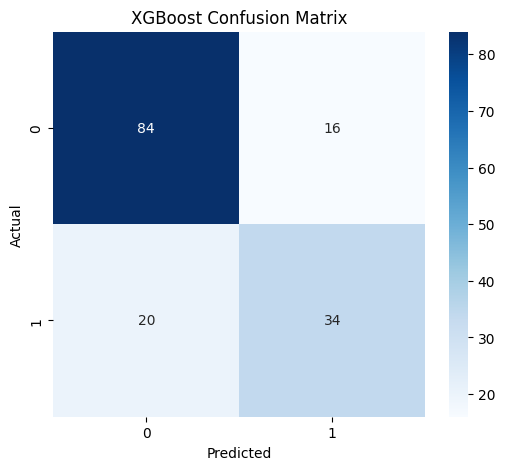

In [32]:
cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [33]:
lgbm_model = LGBMClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    num_leaves=15,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=-1
)
lgbm_model.fit(
    X_train,
    y_train
)

,boosting_type,'gbdt'
,num_leaves,15
,max_depth,3
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [34]:
y_pred_lgbm = lgbm_model.predict(X_test)
y_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

In [35]:
lgbm_accuracy = accuracy_score(
    y_test,
    y_pred_lgbm
)
lgbm_precision = precision_score(
    y_test,
    y_pred_lgbm
)
lgbm_recall = recall_score(
    y_test,
    y_pred_lgbm
)
lgbm_f1 = f1_score(
    y_test,
    y_pred_lgbm
)
lgbm_auc = roc_auc_score(
    y_test,
    y_prob_lgbm
)
print("LightGBM Performance")
print("-------------------------")
print("Accuracy :", round(lgbm_accuracy, 4))
print("Precision:", round(lgbm_precision, 4))
print("Recall   :", round(lgbm_recall, 4))
print("F1 Score :", round(lgbm_f1, 4))
print("ROC-AUC  :", round(lgbm_auc, 4))

LightGBM Performance
-------------------------
Accuracy : 0.7922
Precision: 0.7292
Recall   : 0.6481
F1 Score : 0.6863
ROC-AUC  : 0.8196


In [36]:
print(
    classification_report(
        y_test,
        y_pred_lgbm
    )
)

              precision    recall  f1-score   support

           0       0.82      0.87      0.84       100
           1       0.73      0.65      0.69        54

    accuracy                           0.79       154
   macro avg       0.77      0.76      0.77       154
weighted avg       0.79      0.79      0.79       154



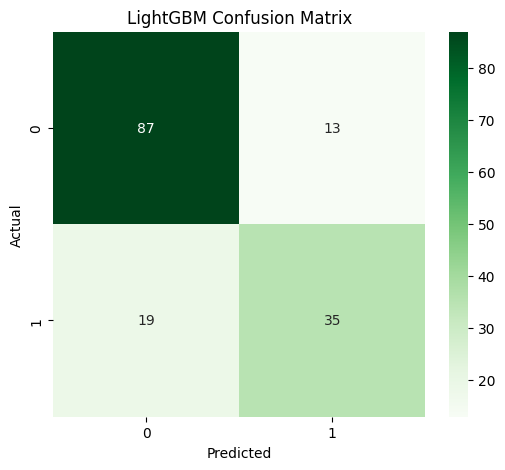

In [37]:
cm_lgbm = confusion_matrix(
    y_test,
    y_pred_lgbm
)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lgbm,
    annot=True,
    fmt='d',
    cmap='Greens'
)
plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [38]:
comparison = pd.DataFrame({
    'Model': [
        'XGBoost',
        'LightGBM'
    ],
    'Accuracy': [
        xgb_accuracy,
        lgbm_accuracy
    ],
    'Precision': [
        xgb_precision,
        lgbm_precision
    ],
    'Recall': [
        xgb_recall,
        lgbm_recall
    ],
    'F1 Score': [
        xgb_f1,
        lgbm_f1
    ],  
    'ROC-AUC': [
        xgb_auc,
        lgbm_auc
    ]
})
comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.7662,0.6800,0.6296,0.6538,0.8256
1,LightGBM,0.7922,0.7292,0.6481,0.6863,0.8196


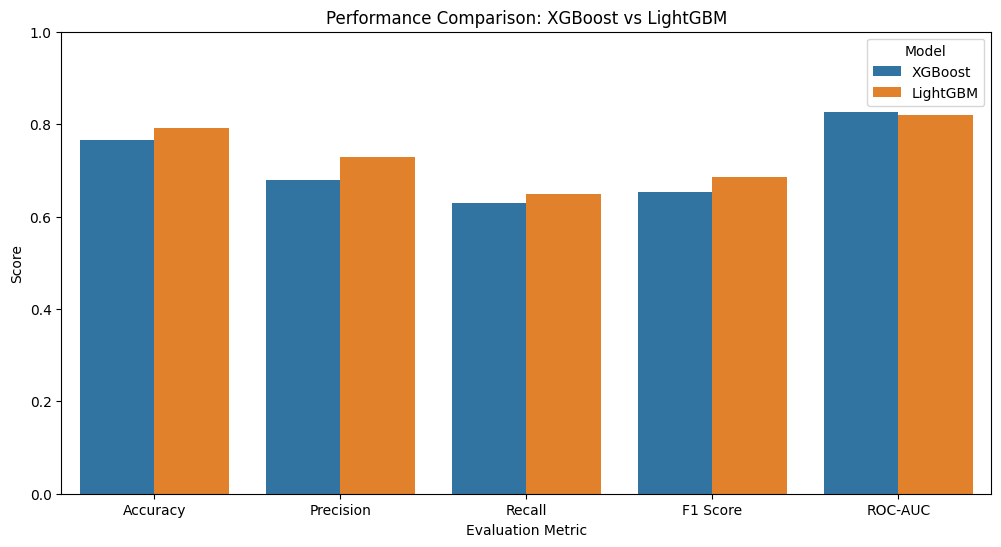

In [39]:
comparison_melted = comparison.melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Score'
)
plt.figure(figsize=(12, 6))
sns.barplot(
    data=comparison_melted,
    x='Metric',
    y='Score',
    hue='Model'
)
plt.title("Performance Comparison: XGBoost vs LightGBM")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.show()

In [40]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [41]:
xgb_cv_scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=cv,
    scoring='f1'
)
print("XGBoost Cross-Validation F1 Scores:")
print(xgb_cv_scores)
print(
    "\nMean XGBoost F1 Score:",
    round(xgb_cv_scores.mean(), 4)
)
print(
    "Standard Deviation:",
    round(xgb_cv_scores.std(), 4)
)

XGBoost Cross-Validation F1 Scores:
[0.69902913 0.65979381 0.66666667 0.65384615 0.62135922]

Mean XGBoost F1 Score: 0.6601
Standard Deviation: 0.0249


In [42]:
lgbm_cv_scores = cross_val_score(
    lgbm_model,
    X,
    y,
    cv=cv,
    scoring='f1'
)
print("LightGBM Cross-Validation F1 Scores:")
print(lgbm_cv_scores)
print(
    "\nMean LightGBM F1 Score:",
    round(lgbm_cv_scores.mean(), 4)
)
print(
    "Standard Deviation:",
    round(lgbm_cv_scores.std(), 4)
)

LightGBM Cross-Validation F1 Scores:
[0.66666667 0.58333333 0.61538462 0.61538462 0.63461538]

Mean LightGBM F1 Score: 0.6231
Standard Deviation: 0.0273


In [43]:
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [44]:
xgb_grid = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    param_grid=xgb_param_grid,
    cv=5,
    scoring='f1',   
    n_jobs=-1
)
xgb_grid.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5], 'n_estimators': [100, 200], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter cand

In [45]:
print("Best XGBoost Parameters:")
print(xgb_grid.best_params_)
print(
    "\nBest XGBoost CV F1 Score:",
    round(xgb_grid.best_score_, 4)
)

Best XGBoost Parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}

Best XGBoost CV F1 Score: 0.6487


In [46]:
lgbm_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [-1, 3, 5],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [15, 31],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [ ]:
lgbm_grid = GridSearchCV(
    estimator=LGBMClassifier(
        random_state=42,
        verbosity=-1
    ),
    param_grid=lgbm_param_grid,
    cv=5,
    scoring='f1',   
    n_jobs=-1
)
lgbm_grid.fit(
    X_train,
    y_train
)

In [ ]:
print("Best LightGBM Parameters:")
print(lgbm_grid.best_params_)
print(
    "\nBest LightGBM CV F1 Score:",
    round(lgbm_grid.best_score_, 4)
)

In [ ]:
best_xgb = xgb_grid.best_estimator_
best_lgbm = lgbm_grid.best_estimator_

In [ ]:
y_pred_xgb_tuned = best_xgb.predict(
    X_test
)
y_prob_xgb_tuned = best_xgb.predict_proba(
    X_test
)[:, 1]
print("Tuned XGBoost")
print("-------------------------")
print(
    "Accuracy :",
    round(
        accuracy_score(
            y_test,
            y_pred_xgb_tuned
        ),
        4
    )
)
print(
    "Precision:",
    round(
        precision_score(
            y_test,
            y_pred_xgb_tuned
        ),
        4
    )
)
print(
    "Recall   :",
    round(
        recall_score(
            y_test,
            y_pred_xgb_tuned
        ),
        4
    )
)
print(
    "F1 Score :",
    round(
        f1_score(
            y_test,
            y_pred_xgb_tuned
        ),
        4
    )
)
print(
    "ROC-AUC  :",
    round(
        roc_auc_score(
            y_test,
            y_prob_xgb_tuned
        ),
        4
    )
)

In [ ]:
y_pred_lgbm_tuned = best_lgbm.predict(X_test)
y_prob_lgbm_tuned = best_lgbm.predict_proba(X_test)[:, 1]
print("Tuned LightGBM")
print("-------------------------")
print(
    "Accuracy :",
    round(
        accuracy_score(
            y_test,
            y_pred_lgbm_tuned
        ),
        4
    )
)
print(
    "Precision:",
    round(
        precision_score(
            y_test,
            y_pred_lgbm_tuned
        ),
        4
    )
)
print(
    "Recall   :",
    round(
        recall_score(
            y_test,
            y_pred_lgbm_tuned
        ),
        4
    )
)
print(
    "F1 Score :",
    round(
        f1_score(
            y_test,
            y_pred_lgbm_tuned
        ),
        4
    )
)
print(
    "ROC-AUC  :",
    round(
        roc_auc_score(
            y_test,
            y_prob_lgbm_tuned
        ),
        4
    )
)

In [ ]:
final_results = pd.DataFrame({    
    'Model': [
        'XGBoost - Initial',
        'LightGBM - Initial',
        'XGBoost - Tuned',
        'LightGBM - Tuned'
    ],
    'Accuracy': [
        xgb_accuracy,
        lgbm_accuracy,
        accuracy_score(
            y_test,
            y_pred_xgb_tuned
        ),
        accuracy_score(
            y_test,
            y_pred_lgbm_tuned
        )
    ],
    'Precision': [
        xgb_precision,
        lgbm_precision,
        precision_score(
            y_test,
            y_pred_xgb_tuned
        ),
        precision_score(
            y_test,
            y_pred_lgbm_tuned
        )
    ],
    'Recall': [
        xgb_recall,
        lgbm_recall,
        recall_score(
            y_test,
            y_pred_xgb_tuned
        ),
        recall_score(
            y_test,
            y_pred_lgbm_tuned
        )
    ], 
    'F1 Score': [
        xgb_f1,
        lgbm_f1,
        f1_score(
            y_test,
            y_pred_xgb_tuned
        ),
        f1_score(
            y_test,
            y_pred_lgbm_tuned
        )
    ],
    'ROC-AUC': [
        xgb_auc,
        lgbm_auc,
        roc_auc_score(
            y_test,
            y_prob_xgb_tuned
        ),
        roc_auc_score(
            y_test,
            y_prob_lgbm_tuned
        )
    ]
})
final_results.round(4)

In [ ]:
final_melted = final_results.melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Score'
)
plt.figure(figsize=(14, 7))
sns.barplot(
    data=final_melted,
    x='Metric',
    y='Score',
    hue='Model'
)
plt.title(
    "Final Performance Comparison of XGBoost and LightGBM"
)
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.show()

In [ ]:
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(
    ascending=False
)
print("XGBoost Feature Importance:")
print(xgb_importance)

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=xgb_importance.values,
    y=xgb_importance.index
)
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
lgbm_importance = pd.Series(
    lgbm_model.feature_importances_,
    index=X.columns
).sort_values(
    ascending=False
)
print("LightGBM Feature Importance:")
print(lgbm_importance)

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=lgbm_importance.values,
    y=lgbm_importance.index
)
plt.title("LightGBM Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    y_prob_xgb
)
fpr_lgbm, tpr_lgbm, _ = roc_curve(
    y_test,
    y_prob_lgbm
)

In [ ]:
plt.figure(figsize=(9, 6))
plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {xgb_auc:.4f})"
)
plt.plot(
    fpr_lgbm,
    tpr_lgbm,
    label=f"LightGBM (AUC = {lgbm_auc:.4f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)
plt.title(
    "ROC Curve: XGBoost vs LightGBM"
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## Feature Importance Interpretation
- The feature importance analysis shows that the most influential predictors differed slightly between XGBoost and LightGBM.
- For XGBoost, Glucose was the most important feature, followed by BMI and Age.
- For LightGBM, BMI had the highest feature importance, followed by Glucose and DiabetesPedigreeFunction.
- These results indicate that Glucose and BMI are among the most influential variables for diabetes prediction in both models.
- The raw feature importance values from XGBoost and LightGBM should not be directly compared because the two algorithms use different methods for calculating feature importance. The rankings within each model are more appropriate for interpretation.

## Final Comparative Analysis
- The performance of XGBoost and LightGBM was evaluated using accuracy, precision, recall, F1-score, and ROC-AUC.
- The initial LightGBM model achieved the best overall performance on the independent test set, with an accuracy of 79.22%, precision of 72.92%, recall of 64.81%, and F1-score of 68.63%.
- The initial XGBoost model achieved an accuracy of 76.62%, precision of 68.00%, recall of 62.96%, and F1-score of 65.38%.
- XGBoost achieved a slightly higher ROC-AUC of 82.56%, compared with 81.96% for LightGBM. This indicates that XGBoost had a marginally better ability to distinguish between the two outcome classes based on predicted probabilities.
- Five-fold stratified cross-validation was also performed using F1-score as the evaluation metric. XGBoost achieved a mean F1-score of approximately 0.6601, while LightGBM achieved a mean F1-score of approximately 0.6231.
- These results show that model performance can vary depending on the data used for evaluation. LightGBM performed better on the independent test set, while XGBoost showed a slightly higher average F1-score across the cross-validation folds.
- Hyperparameter tuning was performed using GridSearchCV. However, the tuned models did not improve the independent test-set performance compared with the initial models.
- The tuned XGBoost model achieved an F1-score of 64.08%, while the tuned LightGBM model achieved an F1-score of 63.37%. Therefore, the initial models were preferred for the final comparison.

## Conclusion
- The experiment successfully compared LightGBM and XGBoost for diabetes classification using the Diabetes dataset.
- Based on the independent test-set results, the initial LightGBM model performed best overall, achieving 79.22% accuracy, 72.92% precision, 64.81% recall, and a 68.63% F1-score.
- XGBoost achieved a slightly higher ROC-AUC of 82.56%, compared with 81.96% for LightGBM. However, LightGBM performed better in accuracy, precision, recall, and F1-score.
- Therefore, the initial LightGBM model was selected as the best-performing model for this particular experiment.
- The feature importance analysis also showed that Glucose and BMI were among the most influential variables for diabetes prediction.
- The experiment demonstrates that both XGBoost and LightGBM are effective gradient boosting algorithms for classification. It also demonstrates that hyperparameter tuning does not necessarily guarantee improved performance on an independent test set.
- For a real-world healthcare application, additional validation, larger datasets, clinical expertise, model calibration, and domain-specific evaluation would be required before using such a model for medical decision-making.